# AlexNet Benchmark

use PY310, py311 not support torch.compile, py39 not support libnvrtc.so compatibility

In [1]:
model_name = "InceptionV3"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll


In [2]:
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [9]:
#recompute, storeall = [
#    ragdoll.compile(x, "gpu", "input", "codegen", benchmark=True) for x in ["recompute.mlir", "storeall.mlir"]
#]
#recompute = ragdoll.compile("recompute.mlir", "gpu", "input", "codegen", benchmark=True)
#storeall = ragdoll.compile("storeall.mlir", "gpu", "input", "codegen", benchmark=True)
!iree-compile recompute.mlir \
-o recompute.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

!iree-compile storeall.mlir \
-o storeall.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

In [10]:
def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo

#recompute_fb, storeall_fb = [
#    load_executable(x) for x in [recompute, storeall]
#]
recompute_fb = load_executable(recompute)
storeall_fb = load_executable(storeall)

## Experimental

In [24]:
import torch
from torch import nn
from torchvision import models
import pandas as pd

MAGIC_NUM = 7777e-5

model = models.inception_v3(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model_dynamo = torch.compile(model, backend="inductor")

device = torch.device("cuda:0")
image = torch.randn(1, 3, 224, 224, requires_grad=True)
image = image.to(device)
model_native = model.to(device)

output_native = model_native(image)
output_dynamo = model_dynamo(image)
grad = torch.randn_like(output_native)

image_np = image.detach().cpu().numpy()
grad_np = grad.cpu().numpy()

df = pd.DataFrame()

### PyTorch (Baseline)

In [25]:
baseline_f = torch_model_benchmark(model_native, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-native-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

# has bug
#baseline_b = torch_model_benchmark(torch.autograd.grad, 
#                                 [output_native, [image], grad], 
#                                 device='gpu',
#                                 warmups=0,
#                                 repetitions=17, 
#                                 measure_count=11)
baseline_b = []
for i in range(11):
  baseline_b += [timeit("torch.autograd.grad(output_native, [image], grad)") / 17.0]
print('torch-native-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Native")])
print(df)

torch-native-gpu-forward:  [7.522118825684576, 7.509541314314394, 7.505660328794928, 7.50696231775424, 7.504754535415594, 7.498131900587503, 7.505939177730505, 7.501224329804673, 7.505543694338377, 7.843915592221654, 7.54057413295788]
7.5403969226913015


RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.cuda.FloatTensor [192]] is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).

In [13]:
baseline_f = torch_model_benchmark(model_dynamo, 
                                 [image], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-forward: ', baseline_f)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output_dynamo, [image], grad], 
                                 device='gpu',
                                 warmups=0,
                                 repetitions=17, 
                                 measure_count=11)
print('torch-dynamo-gpu-backward: ', baseline_b)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

torch-dynamo-gpu-forward:  [9.47885138585287, 8.376428309608908, 8.404753554393263, 8.752907023710362, 8.405830437207923, 8.83887949235299, 8.40049494496163, 8.505685035796725, 8.900952196734794, 8.507751476238756, 8.781962589744259]
8.66859058605477
torch-dynamo-gpu-backward:  [9.143497520948157, 8.169855867676874, 8.170514093602405, 8.184624014093595, 8.183406939839616, 8.184830822488841, 8.194169248728192, 8.200272753396455, 8.197848630302092, 8.178416256080656, 8.197175010162242]
8.273146468847193
        time      pass          item
0   8.668591   Forward  Torch Dynamo
0   8.273146  Backward  Torch Dynamo
0  16.941737      Full  Torch Dynamo


### Nabla without Optim

In [14]:
f1 = []
for i in range(11):
  f1 += [timeit("recompute_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)


print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

f2 = np.mean(f2)

print(f1)
print(f2)

ragdoll-opt1-gpu-forward in timeit:  [0.4616848477984176, 0.4537890835062546, 0.45187364606296315, 0.4517848811605397, 0.4515791361165397, 0.4517091377912199, 0.4516874248271479, 0.45183974592124715, 0.45290959396344777, 0.4521537440664628, 0.4518360272049904]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.399]
0.4529861153108392
0.39990909090909094


In [15]:
b1 = []
for i in range(11):
    b1 += [timeit("recompute_fb.dforward(grad_np)") /  17.0]
print('ragdoll-opt1-gpu-backward in timeit: ', b1)
# TODO(albert): unresolved value error
"""
b2 = ragdoll_model_benchmark(
    recompute,
    "dforward",
    [(1, 1000)],
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print(b2)
"""
df = pd.concat([df, get_dataframe(f2, np.mean(b1), "Nabla-opt1")])
print(df)

ragdoll-opt1-gpu-backward in timeit:  [0.9114164744010743, 0.9099306500352481, 0.9097580841797239, 0.9098515758181319, 0.9098565682549687, 0.9096411445780712, 0.9096712076707798, 0.9097657527993707, 0.9098471317659406, 0.9095030343707871, 0.9095338222515934]
        time      pass          item
0   8.668591   Forward  Torch Dynamo
0   8.273146  Backward  Torch Dynamo
0  16.941737      Full  Torch Dynamo
0   0.399909   Forward    Nabla-opt1
0   0.909889  Backward    Nabla-opt1
0   1.309798      Full    Nabla-opt1


### Nabla with Optim

In [16]:
f1 = []
for i in range(11):
  f1 += [timeit("storeall_fb.forward(image_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', f1)
f1 = np.mean(f1)

f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='gpu',
    warmups=2,
    repetitions=17, 
    measure_count=11)
print('ragdoll-opt1-gpu-forward in benchmark: ', f2)

b1 = []
for i in range(11):
    b1 += [timeit("storeall_fb.dforward(grad_np)") / 17.0]
print('ragdoll-opt1-gpu-forward in timeit: ', b1)
b1 = np.mean(b1)


df = pd.concat([df, get_dataframe(np.mean(f2), b1, "Nabla-opt2")])
print(df)

ragdoll-opt1-gpu-forward in timeit:  [0.4506354357170708, 0.4502362308695036, 0.4499968754894593, 0.4500816488528953, 0.4497580958859009, 0.4487000520834151, 0.4492598613176276, 0.4501302003422204, 0.45017064220326786, 0.4500619349453379, 0.4498881967190434]
(1, 3, 224, 224)
['1x3x224x224xf32']
ragdoll-opt1-gpu-forward in benchmark:  [0.418, 0.418, 0.418, 0.418, 0.418, 0.418, 0.418, 0.418, 0.418, 0.418, 0.418]
ragdoll-opt1-gpu-forward in timeit:  [0.6313115117304465, 0.6279943308190388, 0.627797126003048, 0.6277907130253666, 0.6280822054866482, 0.6276698646080845, 0.6277624479330638, 0.6279040303300408, 0.6280996151925886, 0.6281332211459384, 0.6277008540928364]
        time      pass          item
0   8.668591   Forward  Torch Dynamo
0   8.273146  Backward  Torch Dynamo
0  16.941737      Full  Torch Dynamo
0   0.399909   Forward    Nabla-opt1
0   0.909889  Backward    Nabla-opt1
0   1.309798      Full    Nabla-opt1
0   0.418000   Forward    Nabla-opt2
0   0.628204  Backward    Nabla-o

In [17]:
df.style.hide(axis="index")

time,pass,item
8.668591,Forward,Torch Dynamo
8.273146,Backward,Torch Dynamo
16.941737,Full,Torch Dynamo
0.399909,Forward,Nabla-opt1
0.909889,Backward,Nabla-opt1
1.309798,Full,Nabla-opt1
0.418000,Forward,Nabla-opt2
0.628204,Backward,Nabla-opt2
1.046204,Full,Nabla-opt2


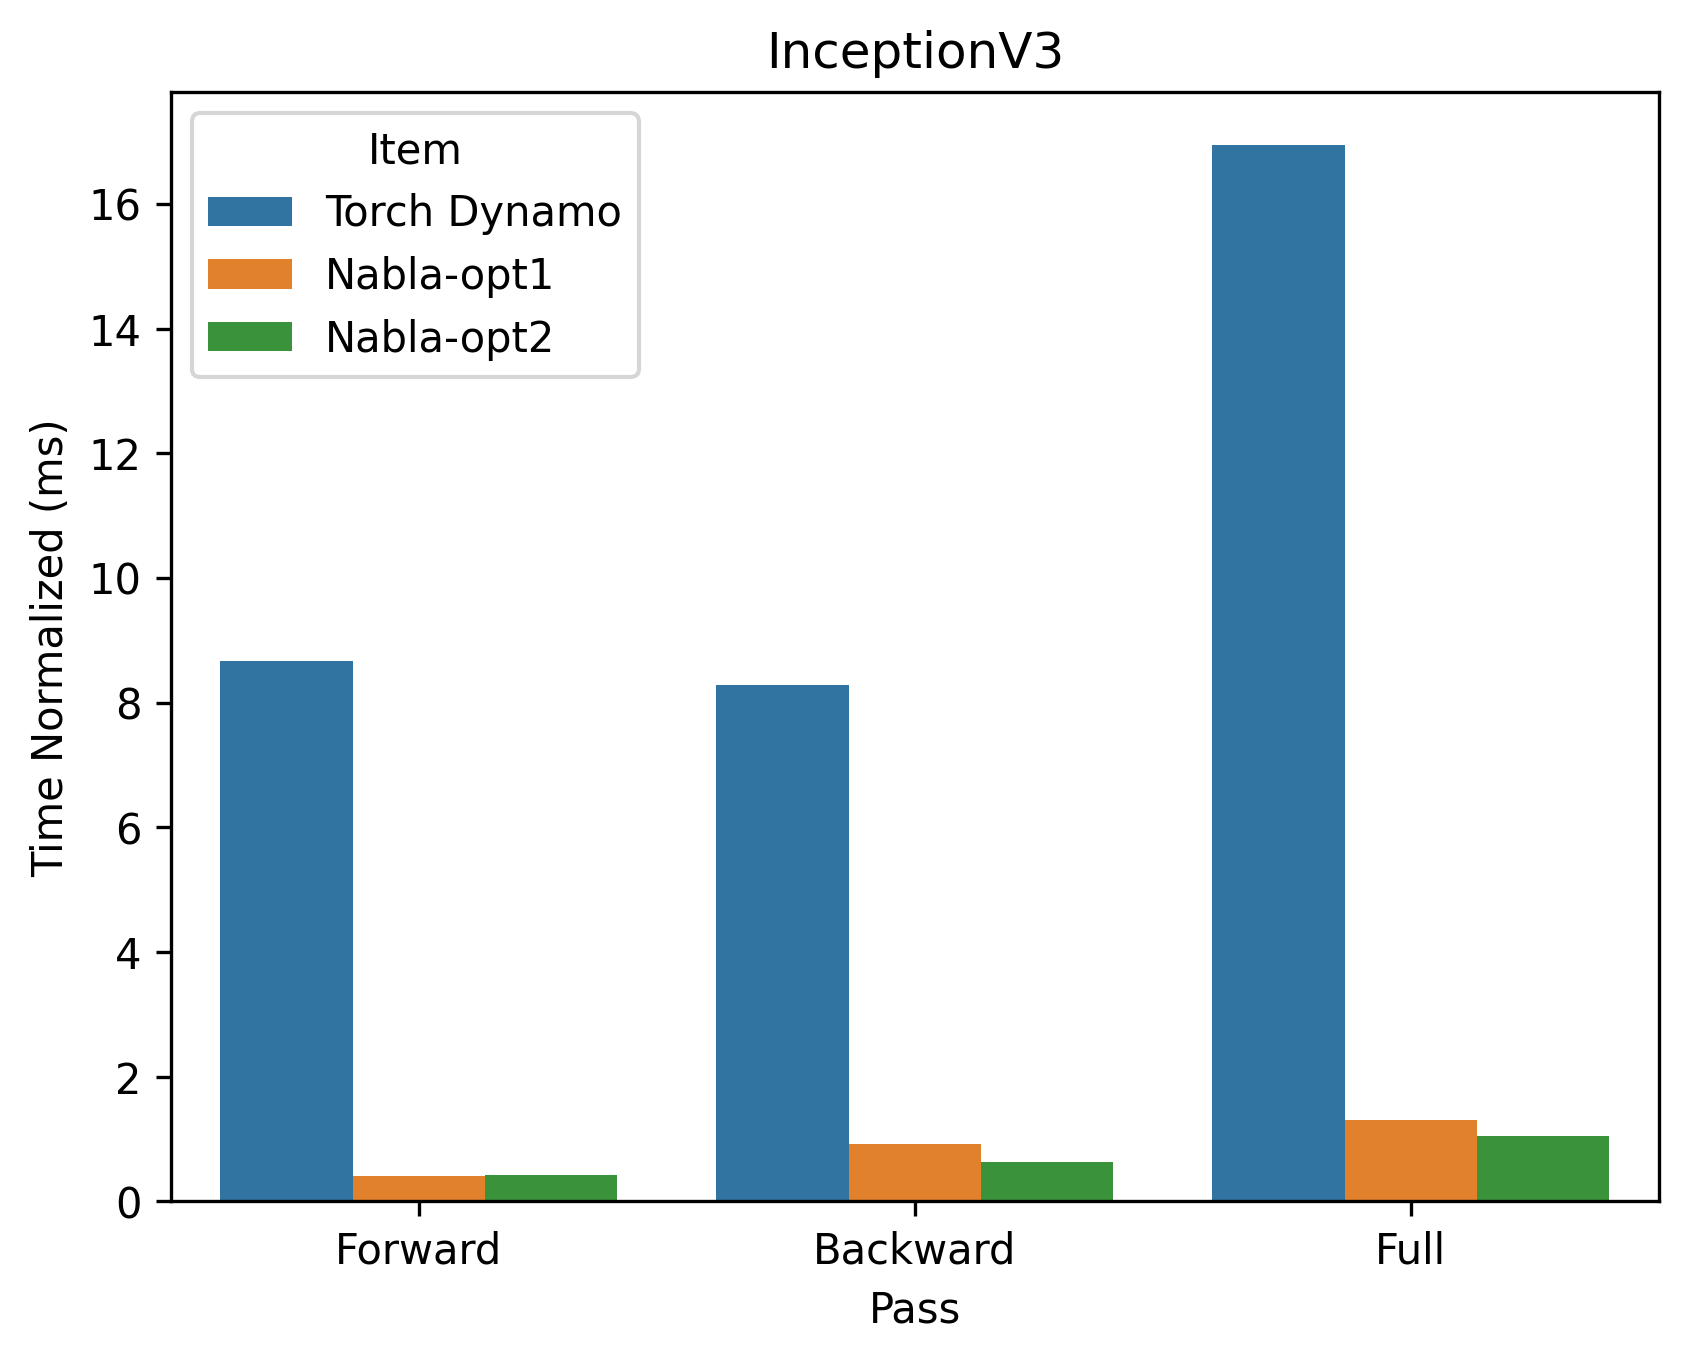

In [18]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [19]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,8.668591,Forward,Torch Dynamo,1.000000
0,0.399909,Forward,Nabla-opt1,21.676403
0,0.418000,Forward,Nabla-opt2,20.738255


In [20]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,8.273146,Backward,Torch Dynamo,1.000000
0,0.909889,Backward,Nabla-opt1,9.092482
0,0.628204,Backward,Nabla-opt2,13.169518


In [21]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,16.941737,Full,Torch Dynamo,1.000000
0,1.309798,Full,Nabla-opt1,12.934620
0,1.046204,Full,Nabla-opt2,16.193528


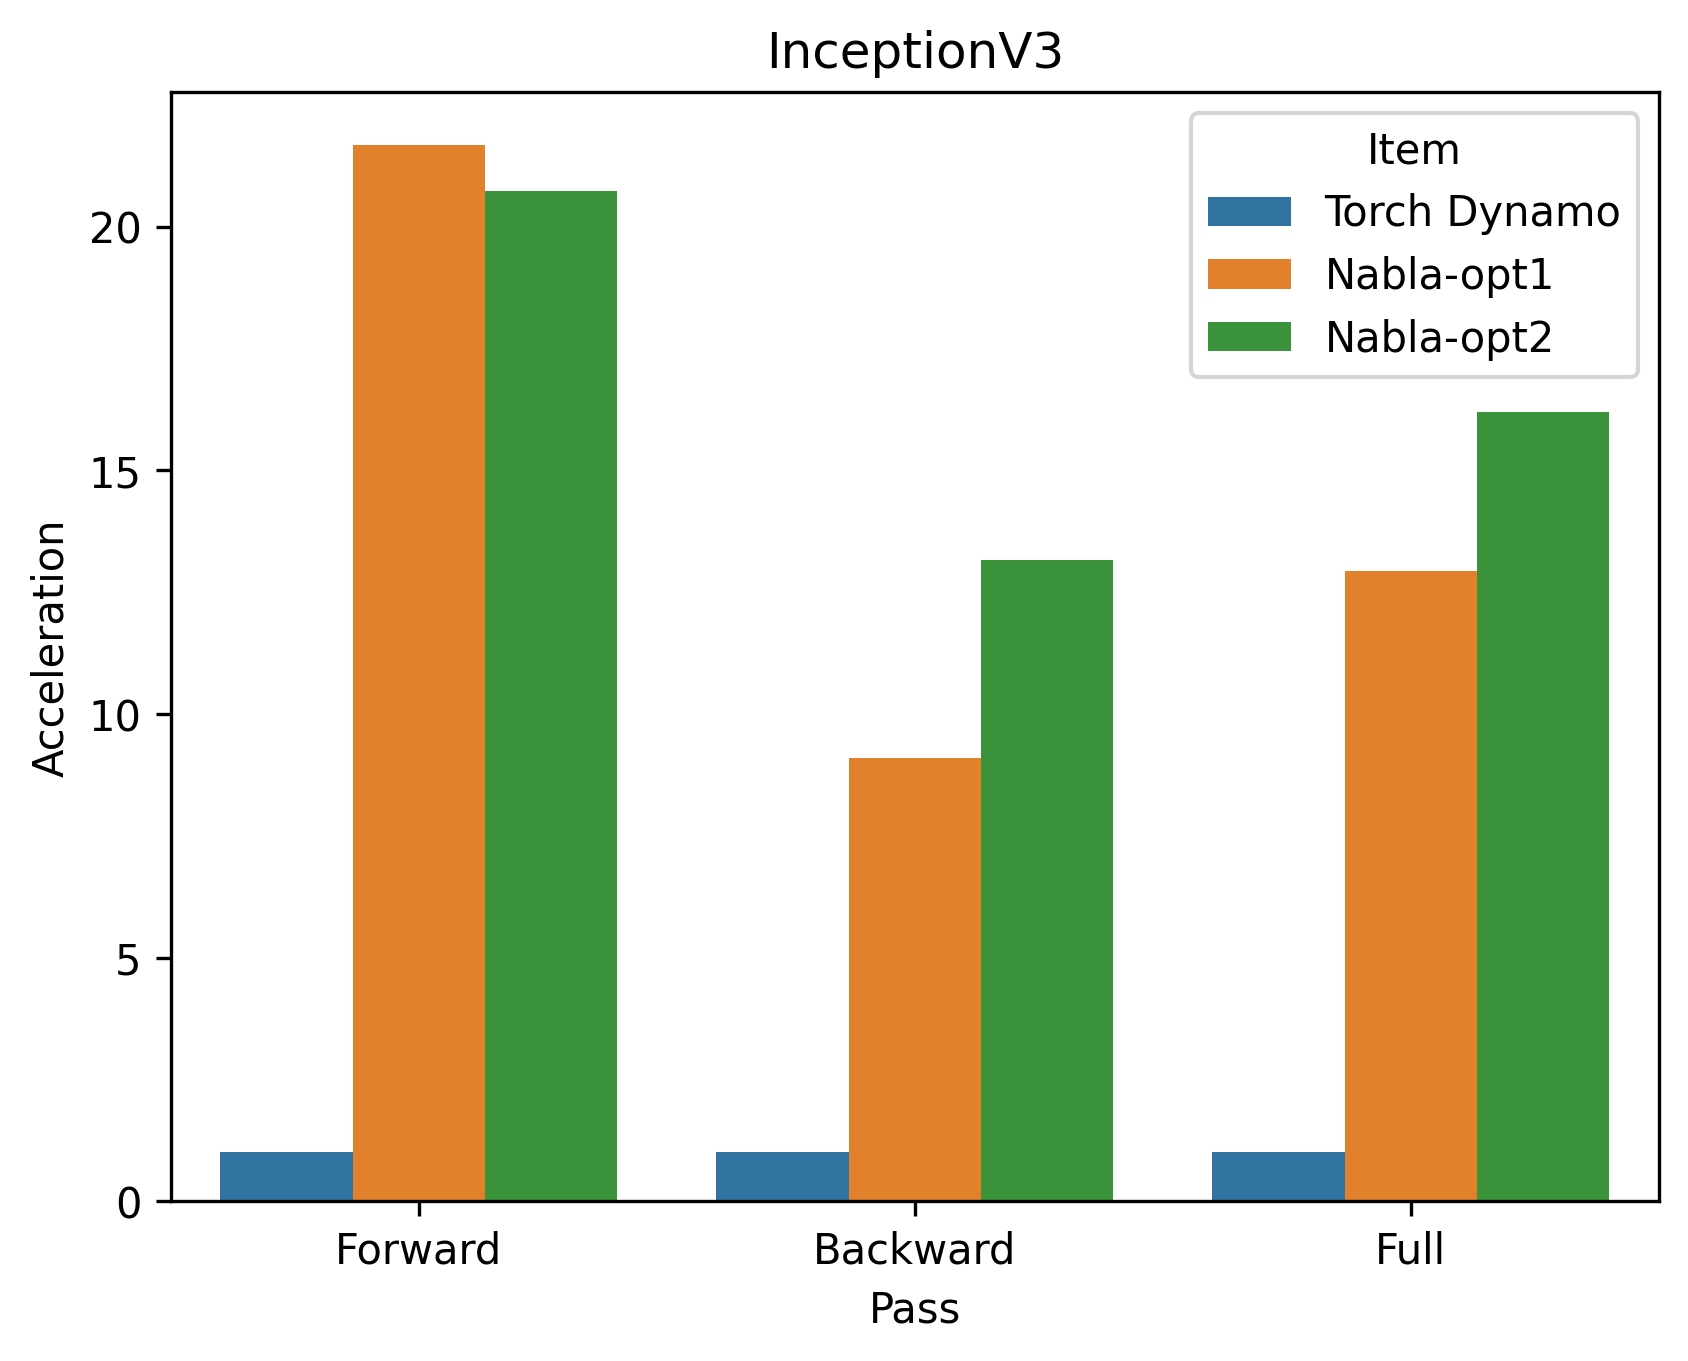

In [22]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")